# 02 — Baltic Dry Index: Ingest & Clean
**MSBA 305 | Maritime Shipping Intelligence Pipeline**

**Source:** Investing.com — Baltic Dry Index historical data (CSV download)
**Output:** `data/clean/bdi_clean.csv`

---
### Data Source Appraisal (Section 4.1.1 of rubric)
| Dimension | Detail |
|-----------|--------|
| **Origin** | Investing.com historical data page for Baltic Dry Index (BDI) |
| **Format** | CSV download |
| **Volume** | ~2,800 daily records (2015–present), grows by trading day |
| **Update frequency** | Daily trading days only |
| **Quality issues** | Weekend/holiday gaps are expected; volume is often blank on the source page |
| **Risks / limitations** | Third-party website export; column names/format may change over time |

**Why this source?** The BDI is a shipping-market indicator that reflects global dry bulk freight conditions. We use it as an external economic/shipping signal to compare against trade patterns from Comtrade.


## 0. Setup

In [2]:
import os, sys, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime
warnings.filterwarnings('ignore')

# ── Environment detection: works in Colab and local/GitHub clone ──────────
try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/repo'
    print('Running in Google Colab')
except ImportError:
    BASE = os.path.abspath(os.path.join(os.getcwd(), '..'))
    print(f'Running locally — BASE: {BASE}')

CLEAN_DIR  = os.path.join(BASE, 'data', 'clean')
RAW_DIR    = os.path.join(BASE, 'data', 'raw')
CLEAN_PATH = os.path.join(CLEAN_DIR, 'bdi_clean.csv')
RAW_PATH   = os.path.join(RAW_DIR,   'bdi_raw.csv')
os.makedirs(CLEAN_DIR, exist_ok=True)

print('Setup complete')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/repo/notebooks
Setup complete
RAW_PATH: /content/drive/MyDrive/repo/data/raw/bdi_raw.csv
CLEAN_PATH: /content/drive/MyDrive/repo/data/clean/bdi_clean.csv


## 1. Load CSV from `data/raw`


In [3]:
raw = pd.read_csv(RAW_PATH)
print(f'Loaded from CSV: {len(raw):,} rows')
print(f'Columns: {raw.columns.tolist()}')
raw.head()


Loaded from CSV: 2,803 rows
Columns: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']


,Date,Price,Open,High,Low,Vol.,Change %
0,04/01/2026,"2,030.00","2,030.00","2,030.00","2,030.00",NaN,1.75%
1,03/31/2026,"1,995.00","1,995.00","1,995.00","1,995.00",NaN,-1.09%
2,03/30/2026,"2,017.00","2,017.00","2,017.00","2,017.00",NaN,-0.69%
3,03/27/2026,"2,031.00","2,031.00","2,031.00","2,031.00",NaN,0.84%
4,03/26/2026,"2,014.00","2,014.00","2,014.00","2,014.00",NaN,0.65%


## 2. Rename & Select Columns

In [11]:
df = raw.copy()
df.rename(columns={
    'Date':'date', 'Price':'bdi_value', 'Open':'bdi_open',
    'High':'bdi_high', 'Low':'bdi_low', 'Vol.':'bdi_volume',
    'Change %':'bdi_change_pct'
}, inplace=True)

keep = [c for c in ['date','bdi_value','bdi_open','bdi_high','bdi_low','bdi_volume','bdi_change_pct'] if c in df.columns]
df = df[keep].copy()

# convert numeric text like '2,030.00' -> 2030.00
for col in ['bdi_value','bdi_open','bdi_high','bdi_low']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', '', regex=False), errors='coerce')

# change % like '1.75%' -> 1.75
if 'bdi_change_pct' in df.columns:
    df['bdi_change_pct'] = pd.to_numeric(
        df['bdi_change_pct'].astype(str)
          .str.replace('%', '', regex=False)
          .str.replace(',', '', regex=False),
        errors='coerce'
    )

# added
for col in ['bdi_open', 'bdi_high', 'bdi_low']:
    if col in df.columns:
        df[col] = df[col].replace(0, np.nan)

# volume is often blank on source; keep as numeric if present
if 'bdi_volume' in df.columns:
    df['bdi_volume'] = pd.to_numeric(
        df['bdi_volume'].astype(str)
          .str.replace(',', '', regex=False)
          .str.replace('K', '000', regex=False)
          .str.replace('M', '000000', regex=False),
        errors='coerce'
    )

print('Columns kept:', df.columns.tolist())
print(f'Rows: {len(df):,}')
df.head(3)


Columns kept: ['date', 'bdi_value', 'bdi_open', 'bdi_high', 'bdi_low', 'bdi_volume', 'bdi_change_pct']
Rows: 2,803


,date,bdi_value,bdi_open,bdi_high,bdi_low,bdi_volume,bdi_change_pct
0,04/01/2026,2030.0,2030.0,2030.0,2030.0,NaN,1.75
1,03/31/2026,1995.0,1995.0,1995.0,1995.0,NaN,-1.09
2,03/30/2026,2017.0,2017.0,2017.0,2017.0,NaN,-0.69


## 3. Handle Missing Values
**Decision:** BDI gaps on weekends/holidays are EXPECTED — they are not errors. We drop rows where `bdi_value` is truly null (data feed failure), but do NOT forward-fill weekend gaps. This preserves the authentic trading-day-only nature of the index.

In [5]:
print('Null counts:')
print(df.isnull().sum())

n = df['bdi_value'].isnull().sum()
df = df[df['bdi_value'].notna()].copy()
print(f'\nDropped {n} rows with null bdi_value')

if 'bdi_volume' in df.columns:
    n2 = df['bdi_volume'].isnull().sum()
    df['bdi_volume'] = df['bdi_volume'].fillna(0)
    print(f'Filled {n2} null bdi_volume values with 0')


Null counts:
date                 0
bdi_value            0
bdi_open             0
bdi_high             0
bdi_low              0
bdi_volume        2803
bdi_change_pct       0
dtype: int64

Dropped 0 rows with null bdi_value
Filled 2803 null bdi_volume values with 0


## 4. Standardize & Sort

In [6]:
df['date'] = pd.to_datetime(df['date'], format='%m/%d/%Y', errors='coerce')
df = df[df['date'].notna()].copy()
df.sort_values('date', inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Date range: {df["date"].min().date()} → {df["date"].max().date()}')


Date range: 2015-01-02 → 2026-04-01


## 5. Add Derived Columns

In [7]:
# recompute daily change after sorting ascending by date
df['daily_change_pct'] = df['bdi_value'].pct_change().mul(100).round(4)
df['rolling_7d_avg']   = df['bdi_value'].rolling(7,  min_periods=1).mean().round(2)
df['rolling_30d_avg']  = df['bdi_value'].rolling(30, min_periods=1).mean().round(2)
df['rolling_90d_avg']  = df['bdi_value'].rolling(90, min_periods=1).mean().round(2)

# market signal: above/below long-term average
overall_mean = df['bdi_value'].mean()
df['above_long_avg']   = df['bdi_value'] > overall_mean

# spike/drop flags (>5% daily move = significant)
df['is_spike'] = df['daily_change_pct'] >  5.0
df['is_drop']  = df['daily_change_pct'] < -5.0

# outliers
std = df['bdi_value'].std()
df['is_outlier'] = (df['bdi_value'] - overall_mean).abs() > 3 * std

# time components for BigQuery grouping
df['year']    = df['date'].dt.year
df['month']   = df['date'].dt.month
df['quarter'] = df['date'].dt.quarter
df['weekday'] = df['date'].dt.day_name()

# source tags
df['source']      = 'investing_bdi_csv'
df['data_type']   = 'freight_index'
df['granularity'] = 'daily'

print('Derived columns added:')
print(df.columns.tolist())
df.head(3)


Derived columns added:
['date', 'bdi_value', 'bdi_open', 'bdi_high', 'bdi_low', 'bdi_volume', 'bdi_change_pct', 'daily_change_pct', 'rolling_7d_avg', 'rolling_30d_avg', 'rolling_90d_avg', 'above_long_avg', 'is_spike', 'is_drop', 'is_outlier', 'year', 'month', 'quarter', 'weekday', 'source', 'data_type', 'granularity']


,date,bdi_value,bdi_open,bdi_high,bdi_low,bdi_volume,bdi_change_pct,daily_change_pct,rolling_7d_avg,rolling_30d_avg,...,is_spike,is_drop,is_outlier,year,month,quarter,weekday,source,data_type,granularity
0,2015-01-02,771.0,771.0,771.0,771.0,0.0,-1.41,NaN,771.00,771.00,...,False,False,False,2015,1,1,Friday,investing_bdi_csv,freight_index,daily
1,2015-01-05,761.0,761.0,761.0,761.0,0.0,-1.30,-1.2970,766.00,766.00,...,False,False,False,2015,1,1,Monday,investing_bdi_csv,freight_index,daily
2,2015-01-06,758.0,758.0,758.0,758.0,0.0,-0.39,-0.3942,763.33,763.33,...,False,False,False,2015,1,1,Tuesday,investing_bdi_csv,freight_index,daily


## 6. Validate

In [8]:
errors = []
if df['bdi_value'].isnull().sum() > 0:      errors.append('FAIL: nulls in bdi_value')
if (df['bdi_value'] < 0).sum() > 0:         errors.append('FAIL: negative BDI')
if df.duplicated('date').sum() > 0:          errors.append('FAIL: duplicate dates')
if errors:
    for e in errors: print(e)
else:
    print('All validation checks PASSED')
    print(f'Shape: {df.shape}')
    print(f'Spikes: {df["is_spike"].sum()} | Drops: {df["is_drop"].sum()}')
    print(f'Outliers: {df["is_outlier"].sum()}')

All validation checks PASSED
Shape: (2803, 22)
Spikes: 144 | Drops: 116
Outliers: 47


## 6. EDA — BDI Over Time with Events


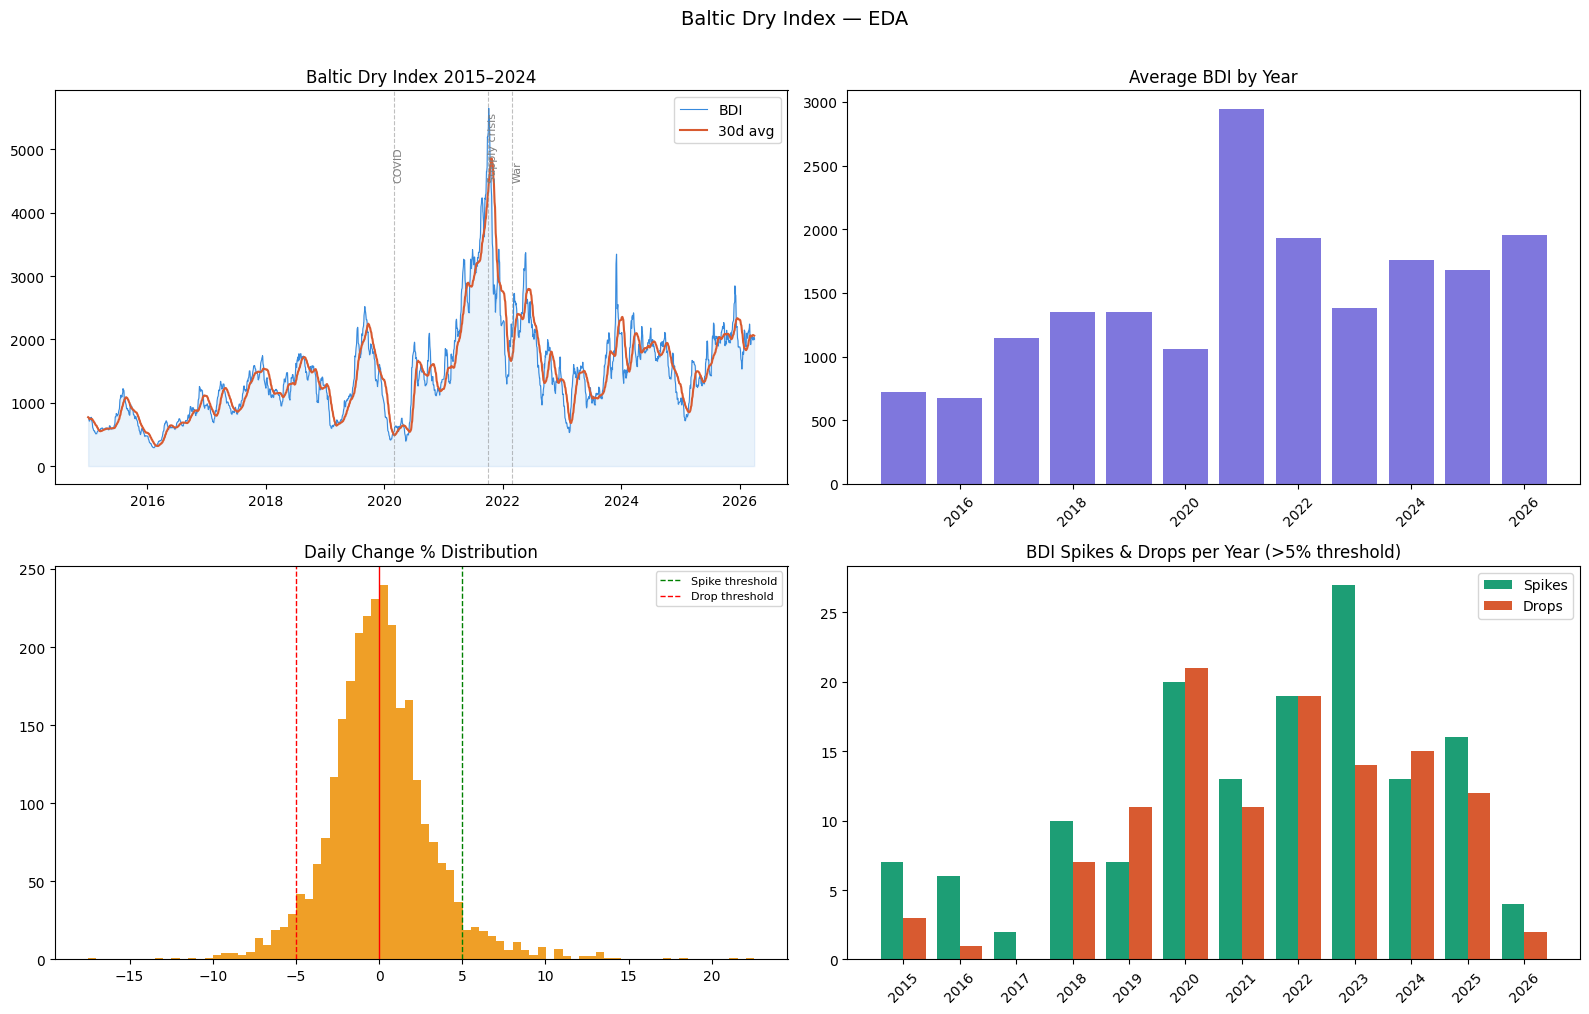

Saved → data/clean/bdi_eda.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16,10))

# BDI over time
axes[0,0].plot(df['date'], df['bdi_value'], color='#378ADD', lw=0.8, label='BDI')
axes[0,0].plot(df['date'], df['rolling_30d_avg'], color='#D85A30', lw=1.5, label='30d avg')
axes[0,0].fill_between(df['date'], df['bdi_value'], alpha=0.1, color='#378ADD')
for d,l in [('2020-03-01','COVID'),('2021-10-01','Supply crisis'),('2022-03-01','War')]:
    axes[0,0].axvline(pd.Timestamp(d), color='gray', ls='--', alpha=0.5, lw=0.8)
    axes[0,0].text(pd.Timestamp(d), df['bdi_value'].max()*0.8, l, rotation=90, fontsize=8, color='gray')
axes[0,0].set_title('Baltic Dry Index 2015–2024')
axes[0,0].legend()

# yearly avg
yearly = df.groupby('year')['bdi_value'].mean()
axes[0,1].bar(yearly.index, yearly.values, color='#7F77DD')
axes[0,1].set_title('Average BDI by Year')
axes[0,1].tick_params(axis='x', rotation=45)

# daily change distribution
axes[1,0].hist(df['daily_change_pct'].dropna(), bins=80, color='#EF9F27', edgecolor='none')
axes[1,0].set_title('Daily Change % Distribution')
axes[1,0].axvline(0, color='red', lw=1)
axes[1,0].axvline(5, color='green', lw=1, ls='--', label='Spike threshold')
axes[1,0].axvline(-5, color='red', lw=1, ls='--', label='Drop threshold')
axes[1,0].legend(fontsize=8)

# spikes & drops per year
spikes = df.groupby('year')['is_spike'].sum()
drops  = df.groupby('year')['is_drop'].sum()
x = np.arange(len(spikes))
axes[1,1].bar(x-0.2, spikes.values, 0.4, label='Spikes', color='#1D9E75')
axes[1,1].bar(x+0.2, drops.values,  0.4, label='Drops',  color='#D85A30')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(spikes.index.astype(str), rotation=45)
axes[1,1].set_title('BDI Spikes & Drops per Year (>5% threshold)')
axes[1,1].legend()

plt.suptitle('Baltic Dry Index — EDA', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{CLEAN_DIR}/bdi_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → data/clean/bdi_eda.png')

## 8. Save Clean Data

In [10]:
df['date'] = df['date'].dt.strftime('%Y-%m-%d')
df.to_csv(CLEAN_PATH, index=False)
print(f'Saved → {CLEAN_PATH}')
print(f'Shape: {df.shape}')
print('DONE — run 03_ingest_clean_weather.ipynb next')

Saved → /content/drive/MyDrive/repo/data/clean/bdi_clean.csv
Shape: (2803, 22)
DONE — run 03_ingest_clean_weather.ipynb next
